In [39]:
import pandas as pd
import matplotlib.pyplot as plt

In [40]:
path = r"C:\Users\Ahmed Al Battashi\Desktop\ML\machine-learning-code-orbit\data\household_power_consumption.zip"
df = pd.read_csv(path, sep=';', low_memory=False)
df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.000,240.430,4.000,0.000,0.000,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.000,4.000,0.000,0.000,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.820,3.800,0.000,0.000,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.700,3.800,0.000,0.000,0.0


# Convert Date and Time to Datetime Index

In [41]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
df.set_index('Datetime', inplace=True)

In [42]:

df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0
...,...,...,...,...,...,...,...,...,...
2010-11-26 20:58:00,26/11/2010,20:58:00,0.946,0.000,240.430,4.000,0.000,0.000,0.0
2010-11-26 20:59:00,26/11/2010,20:59:00,0.944,0.000,240.000,4.000,0.000,0.000,0.0
2010-11-26 21:00:00,26/11/2010,21:00:00,0.938,0.000,239.820,3.800,0.000,0.000,0.0


## Time Slicing

In [43]:
# Data for January 2007
january_2007 = df.loc['2007-01']
january_2007.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2007-01-01 00:00:00,1/1/2007,00:00:00,2.580,0.136,241.970,10.600,0.000,0.000,0.0
2007-01-01 00:01:00,1/1/2007,00:01:00,2.552,0.100,241.750,10.400,0.000,0.000,0.0
2007-01-01 00:02:00,1/1/2007,00:02:00,2.550,0.100,241.640,10.400,0.000,0.000,0.0
2007-01-01 00:03:00,1/1/2007,00:03:00,2.550,0.100,241.710,10.400,0.000,0.000,0.0
2007-01-01 00:04:00,1/1/2007,00:04:00,2.554,0.100,241.980,10.400,0.000,0.000,0.0


In [44]:
# Data for a specific day
day_data = df.loc['2007-01-15']
day_data.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
Datetime,,,,,,,,,
2007-01-15 00:00:00,15/1/2007,00:00:00,1.382,0.104,242.120,5.600,0.000,0.000,18.0
2007-01-15 00:01:00,15/1/2007,00:01:00,1.358,0.100,241.700,5.600,0.000,0.000,17.0
2007-01-15 00:02:00,15/1/2007,00:02:00,1.352,0.096,241.030,5.600,0.000,0.000,18.0
2007-01-15 00:03:00,15/1/2007,00:03:00,1.356,0.098,241.280,5.600,0.000,0.000,18.0
2007-01-15 00:04:00,15/1/2007,00:04:00,1.360,0.100,241.870,5.600,0.000,0.000,18.0


## Resampling Data

In [45]:
df['Global_active_power']

Datetime
2006-12-16 17:24:00    4.216
2006-12-16 17:25:00    5.360
2006-12-16 17:26:00    5.374
2006-12-16 17:27:00    5.388
2006-12-16 17:28:00    3.666
                       ...  
2010-11-26 20:58:00    0.946
2010-11-26 20:59:00    0.944
2010-11-26 21:00:00    0.938
2010-11-26 21:01:00    0.934
2010-11-26 21:02:00    0.932
Name: Global_active_power, Length: 2075259, dtype: object

## Weekly Average Consumption

In [46]:
# Convert to numeric, coerce errors to NaN
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')
weekly = df['Global_active_power'].resample('W').mean()
weekly.head()

Datetime
2006-12-17    2.505248
2006-12-24    1.734186
2006-12-31    1.958376
2007-01-07    1.484233
2007-01-14    1.604954
Freq: W-SUN, Name: Global_active_power, dtype: float64

## Montly Average Consumption 

In [47]:
monthly = df['Global_active_power'].resample('M').mean()
monthly.head()

C:\Users\Ahmed Al Battashi\AppData\Local\Temp\ipykernel_25144\1061418571.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['Global_active_power'].resample('M').mean()


Datetime
2006-12-31    1.901295
2007-01-31    1.546034
2007-02-28    1.401084
2007-03-31    1.318627
2007-04-30    0.891189
Freq: ME, Name: Global_active_power, dtype: float64

## Plotting Monthly Consumption Trend

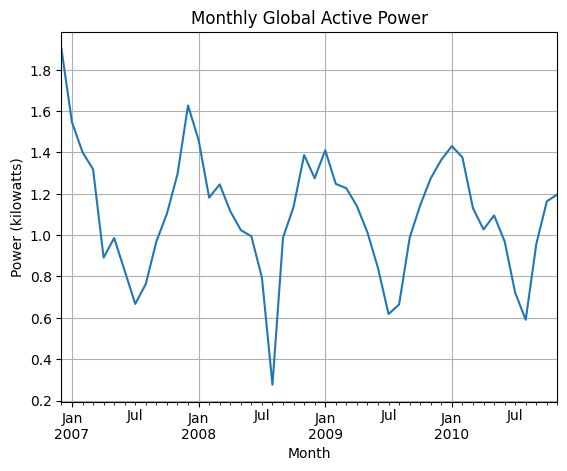

In [48]:
monthly.plot(title='Monthly Global Active Power')
plt.xlabel('Month')
plt.ylabel('Power (kilowatts)')
plt.grid(True)
plt.show()

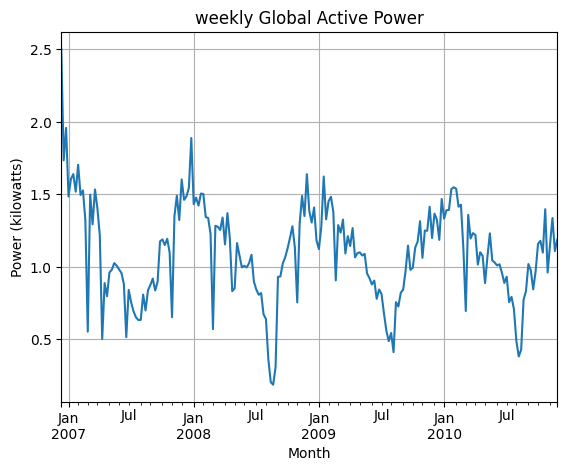

In [49]:
weekly.plot(title='weekly Global Active Power')
plt.xlabel('Month')
plt.ylabel('Power (kilowatts)')
plt.grid(True)
plt.show()